# One tonne of CO₂: an AR6 causal chain

This is the executable companion to the narrative page. It follows one idea at a time: a **1 t CO₂ pulse** becomes atmospheric burden, instantaneous effective radiative forcing, and then a temperature response. The structure mirrors the causal chain in AR6 Figure TS.4; GWP and emission profiles come later.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from radiativeforcing.ar6.co2 import co2_agwp, co2_pulse_response

years = np.linspace(0, 500, 1001)
pulse = co2_pulse_response(years, emission_mass_kg=1000.0)

## 1. One brief emission leaves a long atmospheric tail

AR6 represents the fraction of a CO₂ pulse remaining at time $t$ as a constant remainder plus three exponential terms:

$$IRF_{CO_2}(t)=a_0+\sum_{i=1}^{3}a_i e^{-t/\tau_i}$$

It is not one lifetime. Fast carbon exchanges remove part of the pulse, while a long-lived fraction remains.

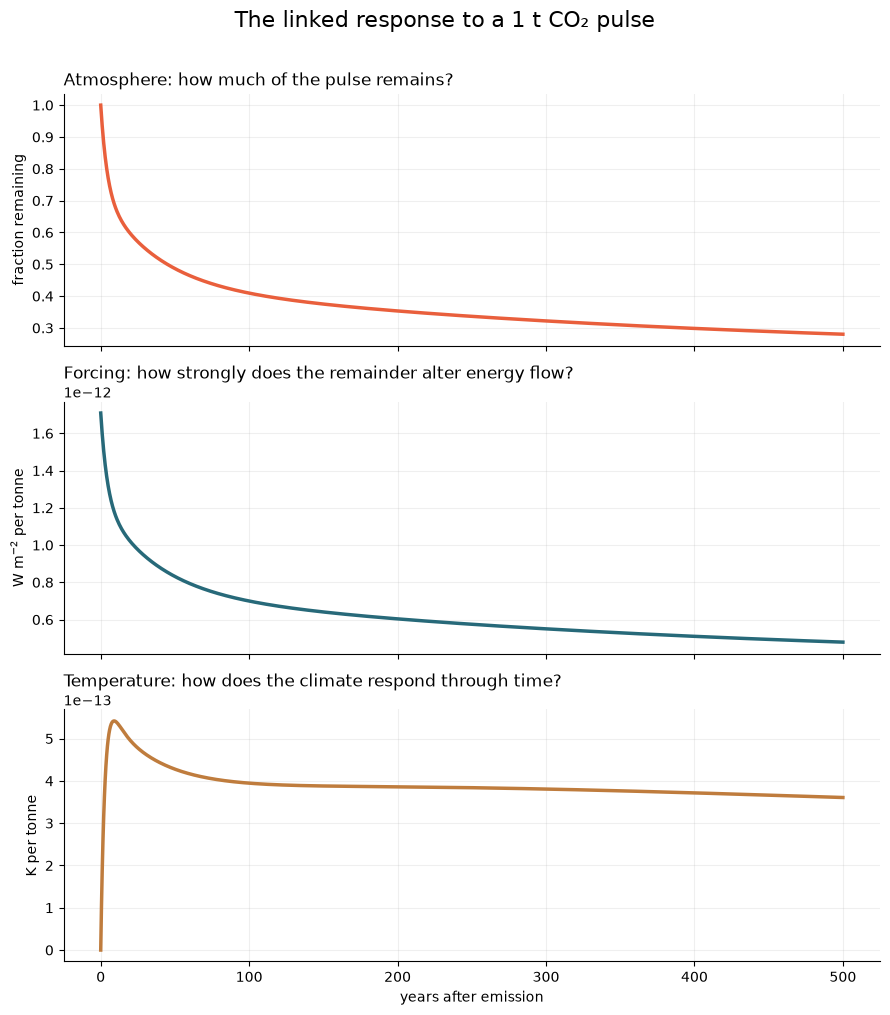

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

axes[0].plot(years, pulse.airborne_fraction, color="#e95f3c", lw=2.5)
axes[0].set_ylabel("fraction remaining")
axes[0].set_title("Atmosphere: how much of the pulse remains?", loc="left")

axes[1].plot(years, pulse.forcing_w_m2, color="#276979", lw=2.5)
axes[1].set_ylabel("W m$^{-2}$ per tonne")
axes[1].set_title("Forcing: how strongly does the remainder alter energy flow?", loc="left")

axes[2].plot(years, pulse.temperature_change_k, color="#bf7c3d", lw=2.5)
axes[2].set_ylabel("K per tonne")
axes[2].set_xlabel("years after emission")
axes[2].set_title("Temperature: how does the climate respond through time?", loc="left")

for ax in axes:
    ax.grid(alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("The linked response to a 1 t CO₂ pulse", fontsize=16, y=1.01)
fig.tight_layout()

## 2. Remaining mass is converted into forcing

For this small pulse, forcing is locally linear: $AGFP(t)=RE_{CO_2}\,IRF_{CO_2}(t)$. The result for one tonne is extremely small because it is averaged over Earth's entire surface. It is **instantaneous forcing**, not heat stored and not the integral under the curve.

Temperature is a further response: $AGTP(t)=\int_0^t AGFP(t')\,R_T(t-t')\,dt'$. The thermal response $R_T$ gives temperature its own timescales; forcing and temperature are therefore not interchangeable.

## 3. Integration produces an operational metric

The absolute global warming potential integrates forcing up to a chosen horizon $H$:

$$AGWP(H)=\int_0^H AGFP(t)\,dt$$

This is why GWP needs a time horizon. The values below are executable checkpoints against the AR6 Chapter 7 supplement—not copied display values.

In [3]:
published = {20: 2.43e-14, 100: 8.95e-14, 500: 3.14e-13}
checkpoints = pd.DataFrame(
    [
        {
            "horizon (years)": horizon,
            "calculated AGWP": float(co2_agwp(horizon)),
            "AR6 published AGWP": expected,
            "relative difference": float(co2_agwp(horizon)) / expected - 1,
        }
        for horizon, expected in published.items()
    ]
)
checkpoints.style.format({
    "calculated AGWP": "{:.4e}",
    "AR6 published AGWP": "{:.3e}",
    "relative difference": "{:+.2%}",
})

,horizon (years),calculated AGWP,AR6 published AGWP,relative difference
0,20,2.4336e-14,2.430e-14,+0.15%
1,100,8.9465e-14,8.950e-14,-0.04%
2,500,3.1380e-13,3.140e-13,-0.06%


### What this notebook deliberately postpones

Multiple gases, GWP ratios, arbitrary emission profiles, and convolution visualizations are the next layers. Keeping the single pulse visible first makes those later operations interpretable rather than merely mathematical. Scientific provenance and the pinned AR6 source commit are documented in `data/ar6/README.md`.